# PCA Comparison: Custom Implementation vs scikit-learn

This notebook compares the `tiaan_pca.PCA` implementation against `sklearn.decomposition.PCA` to:

1. Validate logical correctness of my implementation.
2. Quantify numerical differences (expected to be small but non-zero).
3. Compare my own `fit_svd` and `fit_eigh` routes.

**Convention reminder**
- Our implementation expects `X` with shape `(d, N)`.
  - rows = features
  - columns = observations
- scikit-learn expects `X` with shape `(N, d)`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SklearnPCA

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "comparison" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tiaan_pca import PCA as TPCA
from tiaan_pca import frobenius_norm, relative_frobenius_norm, mse

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)

## Load Data and Prepare Shapes

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "YM_vol.csv"

df = pd.read_csv(DATA_PATH)
X_sklearn = df.to_numpy()      # shape (N, d), for sklearn
X_custom = X_sklearn.T         # shape (d, N), for your PCA

N, d = X_sklearn.shape
print(f"Dataset shape for sklearn: X_sklearn = {X_sklearn.shape} (N, d)")
print(f"Dataset shape for custom PCA: X_custom = {X_custom.shape} (d, N)")

feature_names = list(df.columns)

Dataset shape for sklearn: X_sklearn = (100, 7) (N, d)
Dataset shape for custom PCA: X_custom = (7, 100) (d, N)


## Fit Models

We use the same `n_components` for all models.

In [3]:
# Keep this adjustable for experiments
n_components = 5

# Custum PCA via SVD
pca_svd = TPCA(n_components=n_components, whiten=False, ddof=0)
Z_svd = pca_svd.fit_svd_transform(X_custom)
Xhat_svd = pca_svd.inverse_transform(Z_svd).T

# Custom PCA via covariance eigendecomposition
pca_eigh = TPCA(n_components=n_components, whiten=False, ddof=0)
Z_eigh = pca_eigh.fit_eigh_transform(X_custom)
Xhat_eigh = pca_eigh.inverse_transform(Z_eigh).T

# sklearn PCA
pca_sk = SklearnPCA(n_components=n_components, svd_solver="full", whiten=False)
Z_sk = pca_sk.fit_transform(X_sklearn)
Xhat_sk = pca_sk.inverse_transform(Z_sk)

print("Done fitting all three models.")
print("Z shapes:")
print("  custom svd  :", Z_svd.shape, "(k, N)")
print("  custom eigh :", Z_eigh.shape, "(k, N)")
print("  sklearn     :", Z_sk.shape, "(N, k)")

Done fitting all three models.
Z shapes:
  custom svd  : (5, 100) (k, N)
  custom eigh : (5, 100) (k, N)
  sklearn     : (100, 5) (N, k)


## Helper Functions for Fair Comparison

PCA eigenvectors are sign-ambiguous (a vector and its negative define the same axis), so we align signs before comparing vectors/scores directly.

In [4]:
def align_component_signs_to_reference(components, reference_components):
    """
    Align sign of each component column in `components` to match reference.

    Parameters
    ----------
    components : ndarray, shape (d, k)
    reference_components : ndarray, shape (d, k)

    Returns
    -------
    aligned_components : ndarray, shape (d, k)
    signs : ndarray, shape (k,)
    """
    dots = np.sum(components * reference_components, axis=0)
    signs = np.sign(dots)
    signs[signs == 0] = 1.0
    return components * signs, signs


def reconstruction_metrics(X_true, X_hat):
    return {
        "frobenius": float(frobenius_norm(X_hat, X_true)),
        "relative_frobenius": float(relative_frobenius_norm(X_hat, X_true)),
        "mse": float(mse(X_hat, X_true)),
    }

## Explained Variance Comparison

In [5]:
ev_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(n_components)],
    "svd_explained_variance": pca_svd.explained_variance,
    "eigh_explained_variance": pca_eigh.explained_variance,
    "sk_explained_variance": pca_sk.explained_variance_,
    "svd_explained_ratio": pca_svd.explained_variance_ratio,
    "eigh_explained_ratio": pca_eigh.explained_variance_ratio,
    "sk_explained_ratio": pca_sk.explained_variance_ratio_,
})

for col_a, col_b, name in [
    ("svd_explained_variance", "sk_explained_variance", "svd_vs_sklearn_ev_abs_diff"),
    ("eigh_explained_variance", "sk_explained_variance", "eigh_vs_sklearn_ev_abs_diff"),
    ("svd_explained_variance", "eigh_explained_variance", "svd_vs_eigh_ev_abs_diff"),
    ("svd_explained_ratio", "sk_explained_ratio", "svd_vs_sklearn_ratio_abs_diff"),
    ("eigh_explained_ratio", "sk_explained_ratio", "eigh_vs_sklearn_ratio_abs_diff"),
    ("svd_explained_ratio", "eigh_explained_ratio", "svd_vs_eigh_ratio_abs_diff"),
]:
    ev_df[name] = np.abs(ev_df[col_a] - ev_df[col_b])

ev_df

,component,svd_explained_variance,eigh_explained_variance,sk_explained_variance,svd_explained_ratio,eigh_explained_ratio,sk_explained_ratio,svd_vs_sklearn_ev_abs_diff,eigh_vs_sklearn_ev_abs_diff,svd_vs_eigh_ev_abs_diff,svd_vs_sklearn_ratio_abs_diff,eigh_vs_sklearn_ratio_abs_diff,svd_vs_eigh_ratio_abs_diff
0,PC1,8.116538e-05,8.116538e-05,8.198523e-05,0.900478,0.900478,0.900478,8.198523e-07,8.198523e-07,2.710505e-20,0.000000e+00,1.110223e-16,1.110223e-16
1,PC2,7.166599e-06,7.166599e-06,7.238989e-06,0.079509,0.079509,0.079509,7.238989e-08,7.238989e-08,5.082198e-21,1.249001e-16,2.775558e-17,9.714451e-17
2,PC3,1.731767e-06,1.731767e-06,1.749259e-06,0.019213,0.019213,0.019213,1.749259e-08,1.749259e-08,4.658681e-21,2.081668e-17,2.428613e-17,4.510281e-17
3,PC4,6.494562e-08,6.494562e-08,6.560163e-08,0.000721,0.000721,0.000721,6.560163e-10,6.560163e-10,3.229313e-21,5.963112e-18,2.959872e-17,3.556183e-17
4,PC5,4.092488e-09,4.092488e-09,4.133827e-09,0.000045,0.000045,0.000045,4.133827e-11,4.133827e-11,6.617445e-24,5.421011e-20,4.065758e-20,9.486769e-20


## Component Direction Similarity

We compare each component direction using cosine similarity after sign alignment to sklearn.

In [6]:
components_sk = pca_sk.components_.T  # sklearn components are (k, d), transpose -> (d, k)
components_svd = pca_svd.principle_components
components_eigh = pca_eigh.principle_components

components_svd_aligned, signs_svd = align_component_signs_to_reference(components_svd, components_sk)
components_eigh_aligned, signs_eigh = align_component_signs_to_reference(components_eigh, components_sk)

cos_svd = np.sum(components_svd_aligned * components_sk, axis=0)
cos_eigh = np.sum(components_eigh_aligned * components_sk, axis=0)
cos_svd_eigh = np.sum(components_svd_aligned * components_eigh_aligned, axis=0)

component_sim_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(n_components)],
    "cosine(svd, sklearn)": cos_svd,
    "cosine(eigh, sklearn)": cos_eigh,
    "cosine(svd, eigh)": cos_svd_eigh,
})

component_sim_df

,component,"cosine(svd, sklearn)","cosine(eigh, sklearn)","cosine(svd, eigh)"
0,PC1,1.0,1.0,1.0
1,PC2,1.0,1.0,1.0
2,PC3,1.0,1.0,1.0
3,PC4,1.0,1.0,1.0
4,PC5,1.0,1.0,1.0


## Score (Projection) Comparison

After sign alignment, compare projected coordinates (`Z`) component-wise.

In [7]:
Z_sk_t = Z_sk.T  # shape (k, N)

# apply component-sign alignment to scores as well
Z_svd_aligned = Z_svd * signs_svd[:, None]
Z_eigh_aligned = Z_eigh * signs_eigh[:, None]

score_rows = []
for i in range(n_components):
    svd_diff = Z_svd_aligned[i] - Z_sk_t[i]
    eigh_diff = Z_eigh_aligned[i] - Z_sk_t[i]
    svd_eigh_diff = Z_svd_aligned[i] - Z_eigh_aligned[i]
    score_rows.append({
        "component": f"PC{i+1}",
        "svd_vs_sklearn_rmse": float(np.sqrt(np.mean(svd_diff**2))),
        "eigh_vs_sklearn_rmse": float(np.sqrt(np.mean(eigh_diff**2))),
        "svd_vs_eigh_rmse": float(np.sqrt(np.mean(svd_eigh_diff**2))),
        "svd_vs_sklearn_max_abs": float(np.max(np.abs(svd_diff))),
        "eigh_vs_sklearn_max_abs": float(np.max(np.abs(eigh_diff))),
    })

score_df = pd.DataFrame(score_rows)
score_df

,component,svd_vs_sklearn_rmse,eigh_vs_sklearn_rmse,svd_vs_eigh_rmse,svd_vs_sklearn_max_abs,eigh_vs_sklearn_max_abs
0,PC1,3.276961e-18,2.710973e-18,1.324508e-18,1.387779e-17,1.322727e-17
1,PC2,1.347157e-18,2.278879e-18,1.312409e-18,6.505213e-18,8.673617e-18
2,PC3,2.411252e-18,2.830174e-18,1.498367e-18,1.127570e-17,1.046255e-17
3,PC4,1.479262e-18,7.048580e-19,1.719383e-18,8.890458e-18,4.119968e-18
4,PC5,1.170067e-19,5.497976e-19,5.430969e-19,4.336809e-19,2.208215e-18


## Reconstruction Error Comparison

Primary correctness check: all implementations should reconstruct similarly for the same `n_components`.

In [8]:
recon_df = pd.DataFrame([
    {"model": "custom_svd", **reconstruction_metrics(X_sklearn, Xhat_svd)},
    {"model": "custom_eigh", **reconstruction_metrics(X_sklearn, Xhat_eigh)},
    {"model": "sklearn", **reconstruction_metrics(X_sklearn, Xhat_sk)},
])

recon_df

,model,frobenius,relative_frobenius,mse
0,custom_svd,0.000555,0.003801,4.405131e-10
1,custom_eigh,0.000555,0.003801,4.405131e-10
2,sklearn,0.000555,0.003801,4.405131e-10


## Cross-Reconstruction Differences (Custom vs sklearn)

These are direct differences between reconstruction matrices.

In [9]:
cross_recon_df = pd.DataFrame([
    {
        "comparison": "Xhat_svd vs Xhat_sklearn",
        "frobenius": float(frobenius_norm(Xhat_svd, Xhat_sk)),
        "relative_frobenius": float(relative_frobenius_norm(Xhat_svd, Xhat_sk)),
        "mse": float(mse(Xhat_svd, Xhat_sk)),
    },
    {
        "comparison": "Xhat_eigh vs Xhat_sklearn",
        "frobenius": float(frobenius_norm(Xhat_eigh, Xhat_sk)),
        "relative_frobenius": float(relative_frobenius_norm(Xhat_eigh, Xhat_sk)),
        "mse": float(mse(Xhat_eigh, Xhat_sk)),
    },
    {
        "comparison": "Xhat_svd vs Xhat_eigh",
        "frobenius": float(frobenius_norm(Xhat_svd, Xhat_eigh)),
        "relative_frobenius": float(relative_frobenius_norm(Xhat_svd, Xhat_eigh)),
        "mse": float(mse(Xhat_svd, Xhat_eigh)),
    },
])

cross_recon_df

,comparison,frobenius,relative_frobenius,mse
0,Xhat_svd vs Xhat_sklearn,5.827962e-17,3.988715e-16,4.852163e-36
1,Xhat_eigh vs Xhat_sklearn,4.579435e-17,3.134211e-16,2.995890e-36
2,Xhat_svd vs Xhat_eigh,5.761205e-17,3.943025e-16,4.741640e-36


## Visual Checks

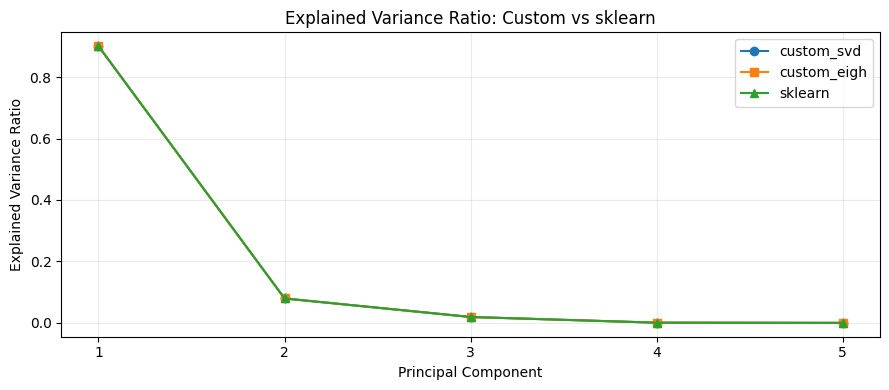

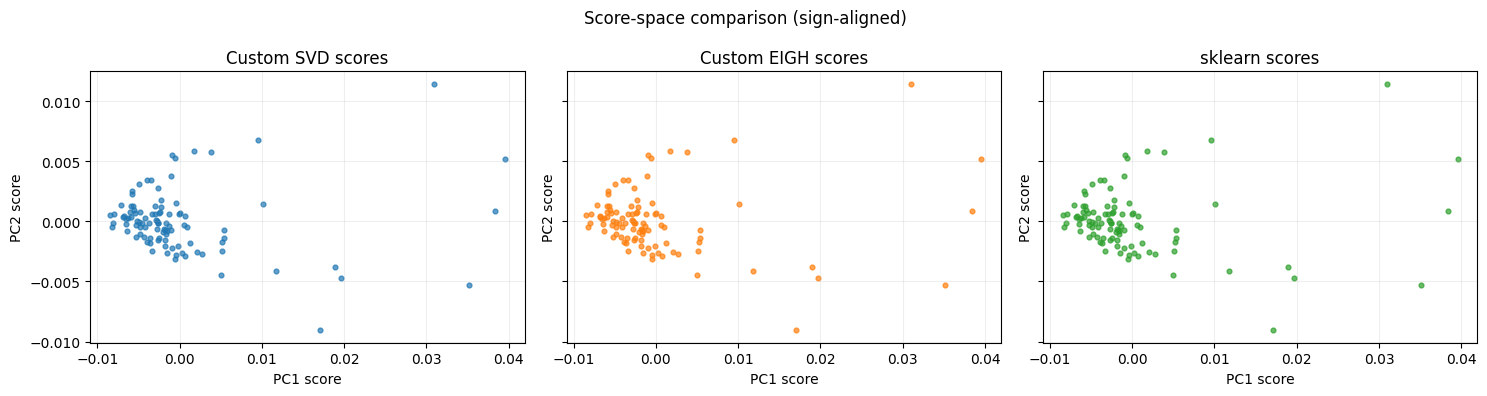

In [10]:
# Explained variance ratio plot
pcs = np.arange(1, n_components + 1)
plt.figure(figsize=(9, 4))
plt.plot(pcs, pca_svd.explained_variance_ratio, marker="o", label="custom_svd")
plt.plot(pcs, pca_eigh.explained_variance_ratio, marker="s", label="custom_eigh")
plt.plot(pcs, pca_sk.explained_variance_ratio_, marker="^", label="sklearn")
plt.xticks(pcs)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio: Custom vs sklearn")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# PC1-PC2 score scatter (after sign alignment)
if n_components >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
    axes[0].scatter(Z_svd_aligned[0], Z_svd_aligned[1], s=12, alpha=0.7)
    axes[0].set_title("Custom SVD scores")
    axes[1].scatter(Z_eigh_aligned[0], Z_eigh_aligned[1], s=12, alpha=0.7, color="tab:orange")
    axes[1].set_title("Custom EIGH scores")
    axes[2].scatter(Z_sk_t[0], Z_sk_t[1], s=12, alpha=0.7, color="tab:green")
    axes[2].set_title("sklearn scores")
    for ax in axes:
        ax.set_xlabel("PC1 score")
        ax.set_ylabel("PC2 score")
        ax.grid(alpha=0.2)
    plt.suptitle("Score-space comparison (sign-aligned)")
    plt.tight_layout()
    plt.show()